In [2]:
import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

## Simulating data
We are simulating thirty trials assuming 35% proportion of left dominance.

In [4]:
example02_df = pd.DataFrame({'Pleft' : np.random.beta(a=3.5, b=10-3.5, size=30)})

## Model definition

$$P_{left} \sim BetaProportion(p, 1/\sigma)$$
$$p \sim Beta(3, 3)$$
$$\sigma \sim Exponential(1)$$

## Compiling the model

In [5]:
example02_model = cmdstanpy.CmdStanModel(stan_file="Stan/example02.stan")

## Preparing the data in Stan format

In [6]:
example02_standata = {
    "N": len(example02_df),
    "Pleft": example02_df.Pleft.to_list()
}

## Sampling the model

In [7]:
example02_fit = example02_model.sample(
    data=example02_standata,
    chains=4,
    parallel_chains=os.cpu_count())

23:22:21 - cmdstanpy - INFO - Requested 8 parallel_chains but only 4 required, will run all chains in parallel.
23:22:21 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

23:22:21 - cmdstanpy - INFO - CmdStan done processing.
23:22:22 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_proportion_lpdf: Location parameter is 1, but must be less than 1.000000 (in 'C:/Users/ba7dr4/AppData/Local/Temp/RtmpgHSQg0/model-b1c41e334b9b.stan', line 12, column 2 to column 40)
Exception: beta_proportion_lpdf: Location parameter is 1, but must be less than 1.000000 (in 'C:/Users/ba7dr4/AppData/Local/Temp/RtmpgHSQg0/model-b1c41e334b9b.stan', line 12, column 2 to column 40)
Consider re-running with show_console=True if the above output is unclear!


## Extracting samples

In [8]:
example02_samples = example02_fit.draws_pd()

## Plot posterior distribution for probability of correct response

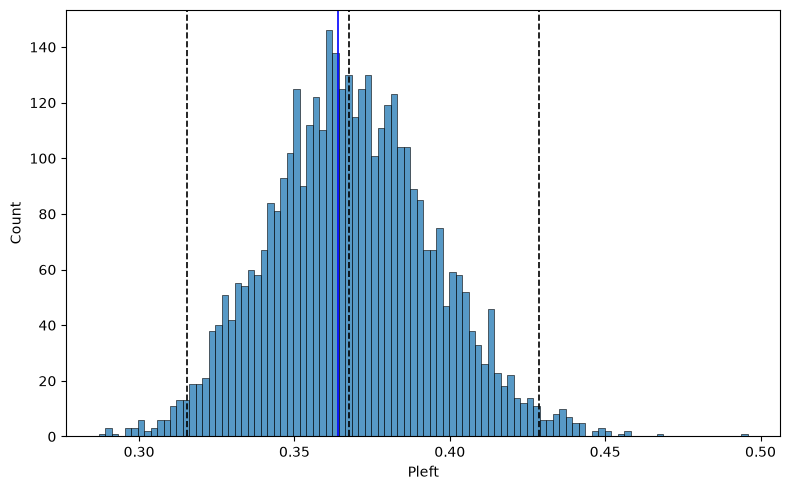

In [9]:
# compute 97% credible interval + median
p_quantiles = np.quantile(example02_samples["p"], [(1 - 0.97) / 2, 0.5, 1 - (1 - 0.97) / 2])

# plot posterior distribution for probability of correct response
plt.figure(figsize=(8, 5))
sns.histplot(example02_samples["p"], bins=100, stat="count")
for x in p_quantiles:
    plt.axvline(x, color="black", linestyle="--", linewidth=1.2)
plt.axvline(example02_df.Pleft.mean(), color="blue", linestyle="-", linewidth=1.2)

plt.xlabel("Pleft")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Compute probability that there are more right than left dominance periods

In [11]:
np.mean(example02_samples['p'] < 0.5)

np.float64(1.0)